# Анализ датасетов решений уравнения Матье с запаздыванием

## Импорт библиотек

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import LogNorm
from tqdm import tqdm

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Загрузка датасетов

In [2]:
datasets_dir = "datasets/"
dataset_files = [f for f in os.listdir(datasets_dir) if f.endswith('dataset.pkl') and f.startswith('mathieu')]
# dataset_files = [f for f in os.listdir(dataset_files) if f.startswith('mathieu')]

print("Найдены датасеты:")
for f in dataset_files:
    print(f"- {f}")

# Загрузка всех датасетов
datasets = {}
for file in tqdm(dataset_files, desc="Загрузка датасетов"):
    path = os.path.join(datasets_dir, file)
    with open(path, 'rb') as f:
        datasets[file] = pickle.load(f)

Найдены датасеты:
- mathieu_delayed_dataset.pkl


Загрузка датасетов: 100%|██████████| 1/1 [00:09<00:00,  9.62s/it]


In [28]:
datasets["mathieu_delayed_dataset.pkl"].keys()

dict_keys(['trajectories', 'config', 'stats', 'generation_info'])

In [32]:
datasets["mathieu_delayed_dataset.pkl"]["trajectories"][0]

{'id': 0,
 'parameters': {'k': 0.181,
  'd': 2.5,
  'e': 0,
  'tau': 6.283185307179586,
  'T': 6.283185307179586,
  'F_ts': 0,
  'F_te': 10,
  'F_T': 2.0943951023931953,
  'b': 0.343905080314186,
  'b_e': 0.41721514930979353,
  'nonlin_k': 0.042055267521432876,
  'F_As': 3.8473095986778096,
  'F_Ae': 3.8473095986778096,
  'b_ts': 1937.6823391999683,
  'b_te': 2312.7616337880777},
 'solution': {'t': array([0.00000e+00, 1.00000e-02, 2.00000e-02, ..., 4.99997e+03,
         4.99998e+03, 4.99999e+03], shape=(500000,)),
  'x': array([0.19029354, 0.16576092, 0.14121466, ..., 0.81154633, 0.87590531,
         0.94034603], shape=(500000,)),
  'x_dot': array([-2.45200698, -2.45422998, -2.4547353 , ...,  6.43105016,
          6.4403671 ,  6.44739314], shape=(500000,))},
 'metadata': {'max_amplitude': 4.227072454129368,
  'mean_amplitude': 0.9265159025777984,
  'std_amplitude': 1.4198854962583454,
  'duration': 4999.990000064886,
  'num_points': 500000,
  'sampling_rate': 99.99999999994884,
  'mean

In [5]:
# datasets

## Анализ метаданных датасетов

In [ ]:
def extract_dataset_info(dataset):
    """Извлекает основную информацию о датасете"""
    return {
        "num_trajectories": len(dataset['trajectories']),
        "success_rate": dataset['generation_info']['success_rate'],
        "generation_time": dataset['generation_info']['generation_time'],
        "file_size": os.path.getsize(os.path.join(datasets_dir, file)) / (1024 * 1024)
    }

# Создаем DataFrame с информацией о датасетах
dataset_info = []
for file, data in datasets.items():
    info = extract_dataset_info(data)
    info["dataset_name"] = file
    dataset_info.append(info)

df_info = pd.DataFrame(dataset_info)
df_info

,num_trajectories,success_rate,generation_time,file_size,dataset_name
0,2000,1.0,962.039841,22889.359145,mathieu_delayed_dataset.pkl


## Визуализация статистики датасетов

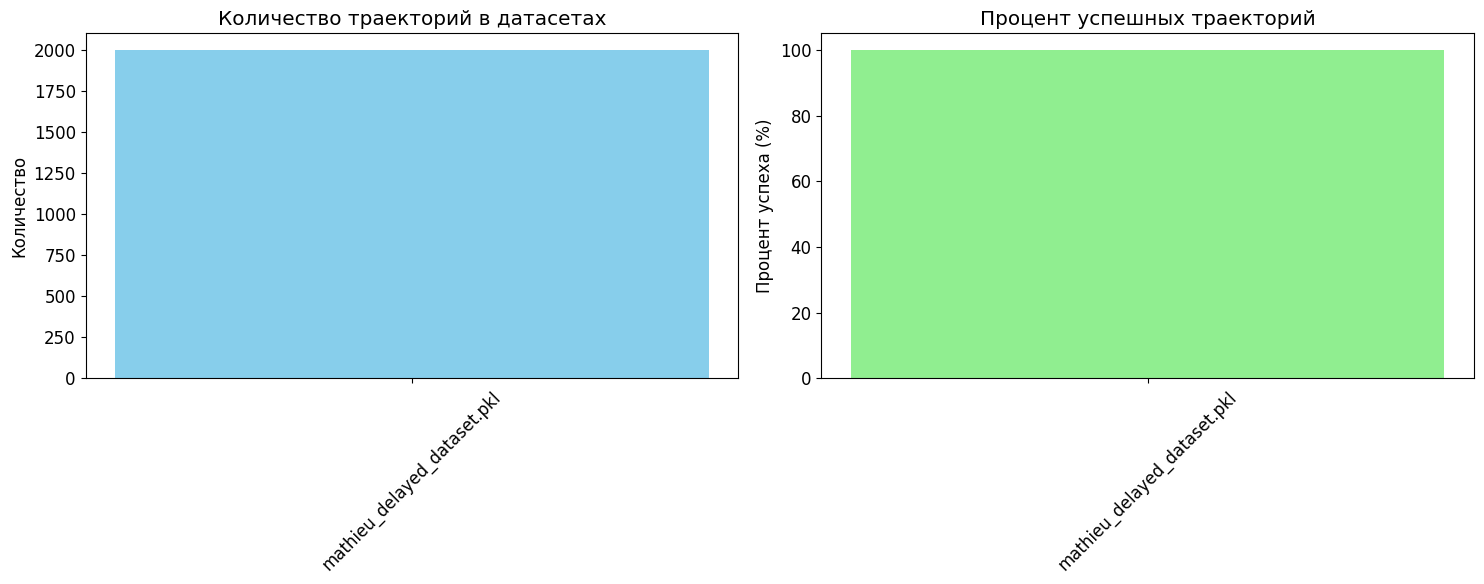

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Количество траекторий
axes[0].bar(df_info['dataset_name'], df_info['num_trajectories'], color='skyblue')
axes[0].set_title('Количество траекторий в датасетах')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Процент успеха
axes[1].bar(df_info['dataset_name'], df_info['success_rate']*100, color='lightgreen')
axes[1].set_title('Процент успешных траекторий')
axes[1].set_ylabel('Процент успеха (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Анализ параметров траекторий

In [14]:
def extract_trajectory_data(trajectory):
    """Извлекает параметры и метаданные траектории"""
    params = trajectory['parameters']
    meta = trajectory['metadata']
    return {
        # 'k': params.get('k'),
        # 'd': params.get('d'),
        # 'e': params.get('e'),
        'b': params.get('b'),
        'b_e': params.get('b_e'),
        'b_ts': params.get('b_ts'),
        'b_te': params.get('b_te'),
        'F_As': params.get('F_As'),
        # 'tau': params.get('tau'),
        'nonlin_k': params.get('nonlin_k'),
        'max_amplitude': meta.get('max_amplitude'),
        'mean_amplitude': meta.get('mean_amplitude'),
        'duration': meta.get('duration'),
        'num_points': meta.get('num_points')
    }

# Создаем DataFrame со всеми траекториями
all_trajectories = []
for dataset_name, dataset in datasets.items():
    for traj in dataset['trajectories']:
        data = extract_trajectory_data(traj)
        data['dataset'] = dataset_name
        all_trajectories.append(data)

df_traj = pd.DataFrame(all_trajectories)
df_traj.head()

,b,b_e,b_ts,b_te,F_As,nonlin_k,max_amplitude,mean_amplitude,duration,num_points,dataset
0,0.343905,0.417215,1937.682339,2312.761634,3.847310,0.042055,4.227072,0.926516,4999.99,500000,mathieu_delayed_dataset.pkl
1,0.333362,0.417626,277.015784,1558.780634,3.293512,0.030002,4.889912,1.931363,4999.99,500000,mathieu_delayed_dataset.pkl
2,0.334880,0.362074,991.004463,1613.945902,3.840736,0.040993,0.980219,0.356374,4999.99,500000,mathieu_delayed_dataset.pkl
3,0.344064,0.416652,1376.755931,2688.879267,4.785894,0.035818,4.614852,1.062436,4999.99,500000,mathieu_delayed_dataset.pkl
4,0.377362,0.403779,648.268487,3928.823364,4.395458,0.049454,3.414471,1.300591,4999.99,500000,mathieu_delayed_dataset.pkl


In [11]:
# traj["metadata"].keys()

## Визуализация распределения параметров

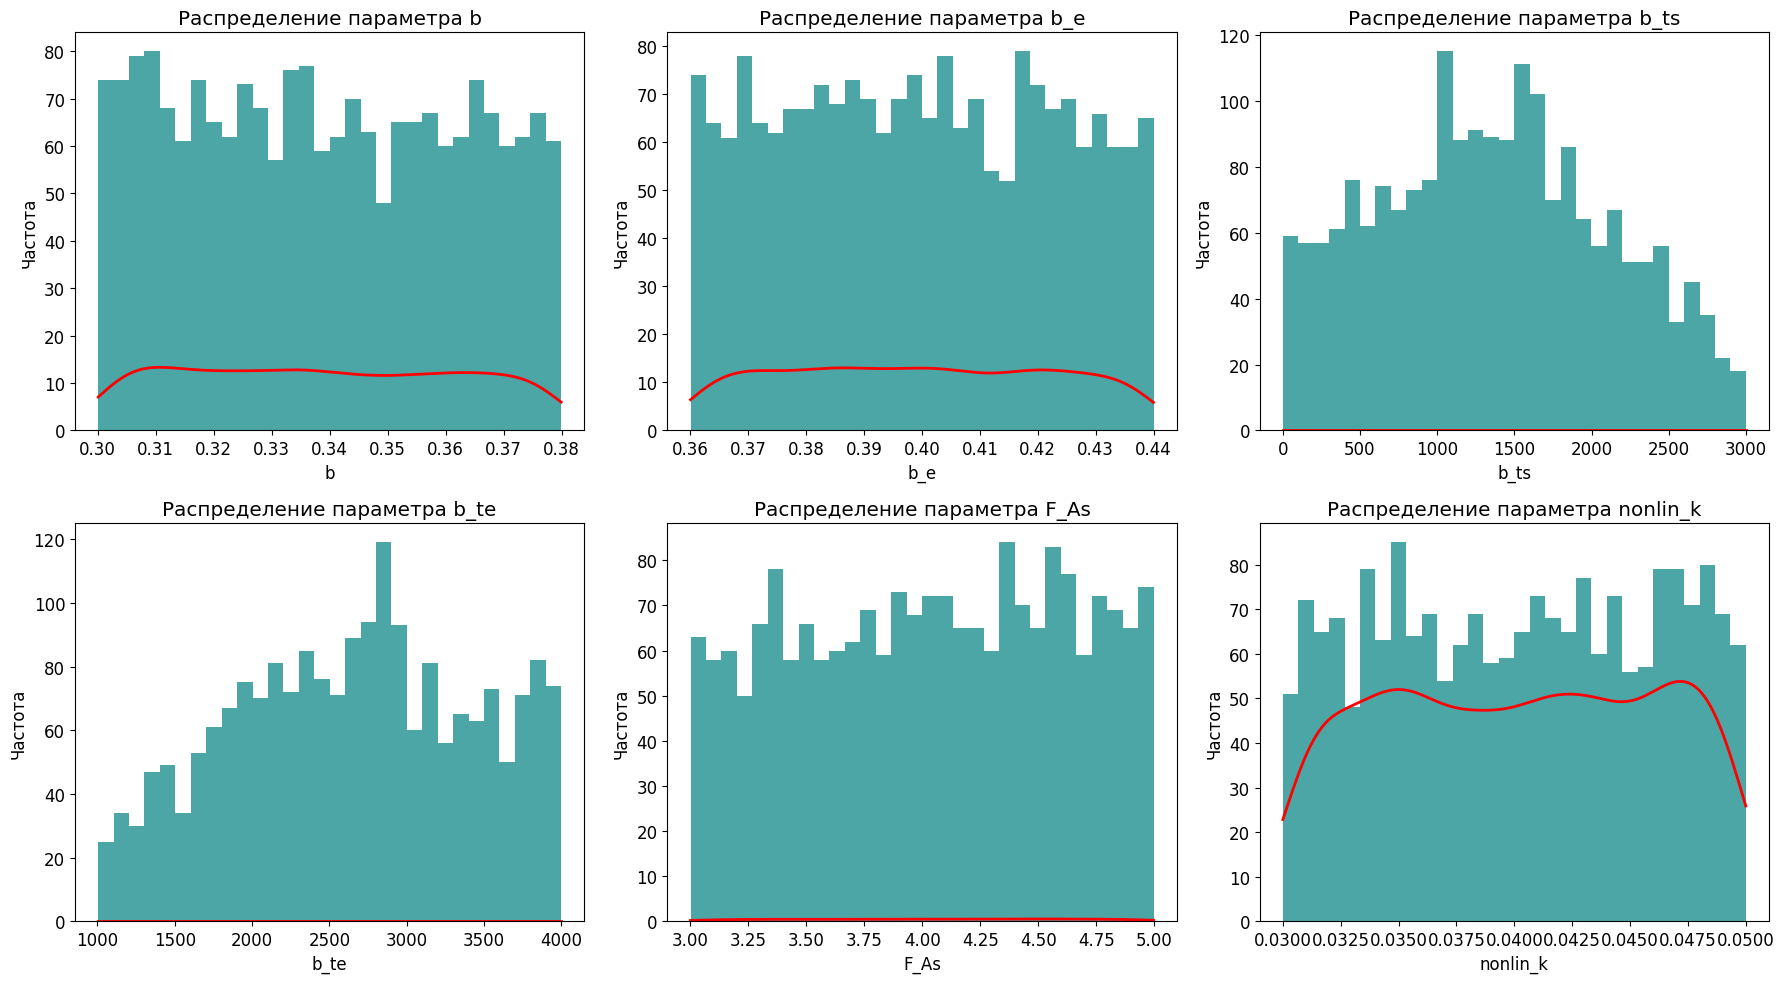

In [15]:
params_to_plot = ['b', 'b_e', 'b_ts', 'b_te', 'F_As', 'nonlin_k']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    if param in df_traj.columns:
        # Гистограмма
        ax.hist(df_traj[param].dropna(), bins=30, alpha=0.7, color='teal')

        # KDE оценка плотности
        if len(df_traj[param].dropna()) > 1:
            kde = gaussian_kde(df_traj[param].dropna())
            x = np.linspace(df_traj[param].min(), df_traj[param].max(), 1000)
            ax.plot(x, kde(x), 'r-', linewidth=2)

        ax.set_title(f'Распределение параметра {param}')
        ax.set_xlabel(param)
        ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

## Корреляционный анализ

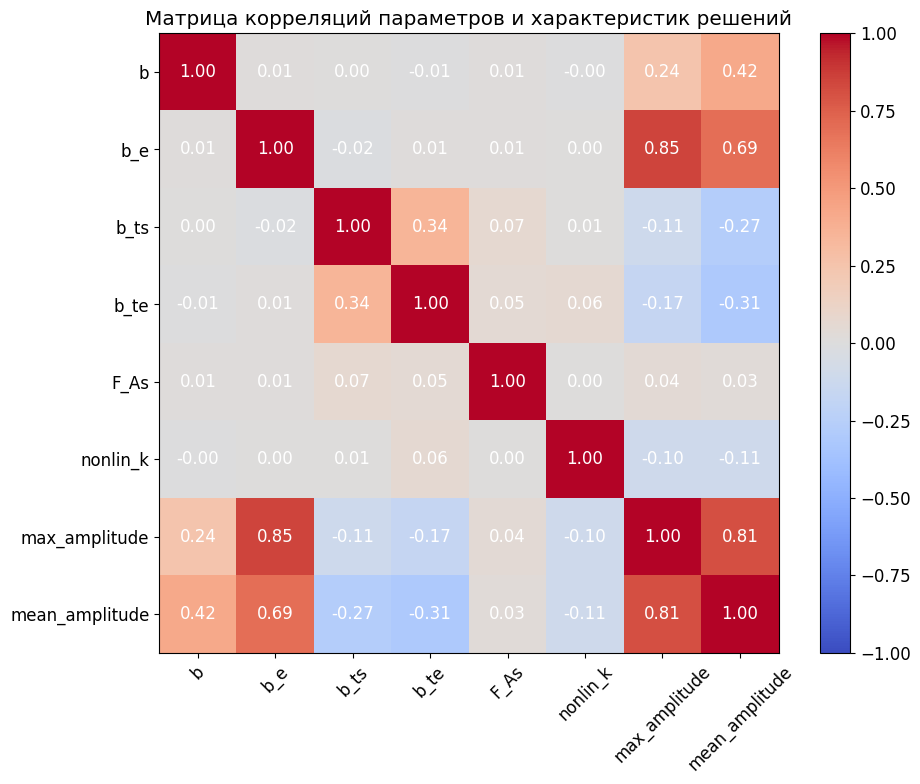

In [16]:
# Матрица корреляций
corr_matrix = df_traj[['b', 'b_e', 'b_ts', 'b_te', 'F_As', 'nonlin_k', 'max_amplitude', 'mean_amplitude']].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Матрица корреляций параметров и характеристик решений')

# Добавление значений корреляции
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

## Визуализация траекторий

{
    "k": 0.181,
    "d": 2.5,
    "e": 0,
    "tau": 6.283185307179586,
    "T": 6.283185307179586,
    "F_ts": 0,
    "F_te": 10,
    "F_T": 2.0943951023931953,
    "b": 0.34406383220596604,
    "b_e": 0.4166518258094484,
    "nonlin_k": 0.03581809477825889,
    "F_As": 4.785893908695309,
    "F_Ae": 4.785893908695309,
    "b_ts": 1376.7559313915087,
    "b_te": 2688.8792668003143
}


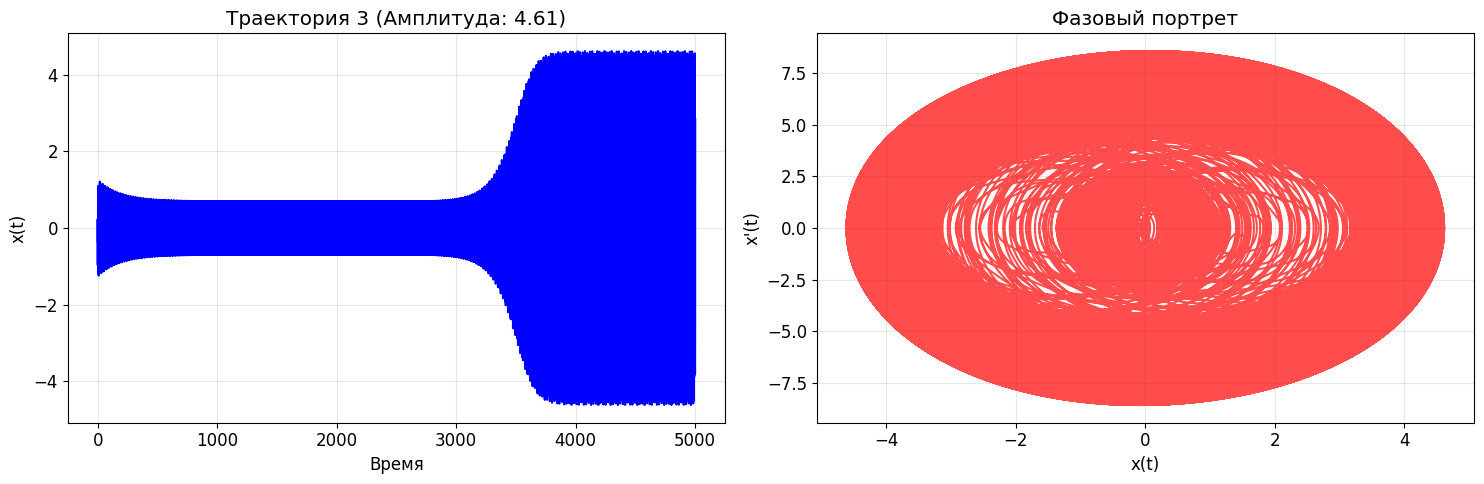

In [23]:
import json
def plot_trajectory(trajectory, ax1, ax2):
    """Визуализирует траекторию"""
    print(json.dumps(trajectory["parameters"], indent=4))
    # print("b", trajectory["parameters"]["b"])
    # print("b_e", trajectory["parameters"]["b_e"])
    t = trajectory['solution']['t']
    x = trajectory['solution']['x']
    x_dot = trajectory['solution']['x_dot']

    # Временной ряд
    ax1.plot(t, x, 'b-')
    ax1.set_xlabel('Время')
    ax1.set_ylabel('x(t)')
    ax1.set_title(f"Траектория {trajectory['id']} (Амплитуда: {trajectory['metadata']['max_amplitude']:.2f})")
    ax1.grid(True, alpha=0.3)

    # Фазовый портрет
    ax2.plot(x, x_dot, 'r-', alpha=0.7)
    ax2.set_xlabel('x(t)')
    ax2.set_ylabel("x'(t)")
    ax2.set_title('Фазовый портрет')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Выбираем случайные траектории для визуализации
sample_trajectories = []
for dataset in datasets.values():
    if dataset['trajectories']:
        # sample_trajectories.append(np.random.choice(dataset['trajectories'], size=10, replace=False))
        sample_trajectories.append(dataset['trajectories'][3])


# sample_trajectories = dataset['trajectories']

# Создаем графики
fig, axes = plt.subplots(len(sample_trajectories), 2, figsize=(15, 5*len(sample_trajectories)))

if len(sample_trajectories) == 1:
    axes = axes.reshape(1, -1)

for i, traj in enumerate(sample_trajectories):
    plot_trajectory(traj, axes[i, 0], axes[i, 1])


## Анализ зависимости амплитуды от параметров

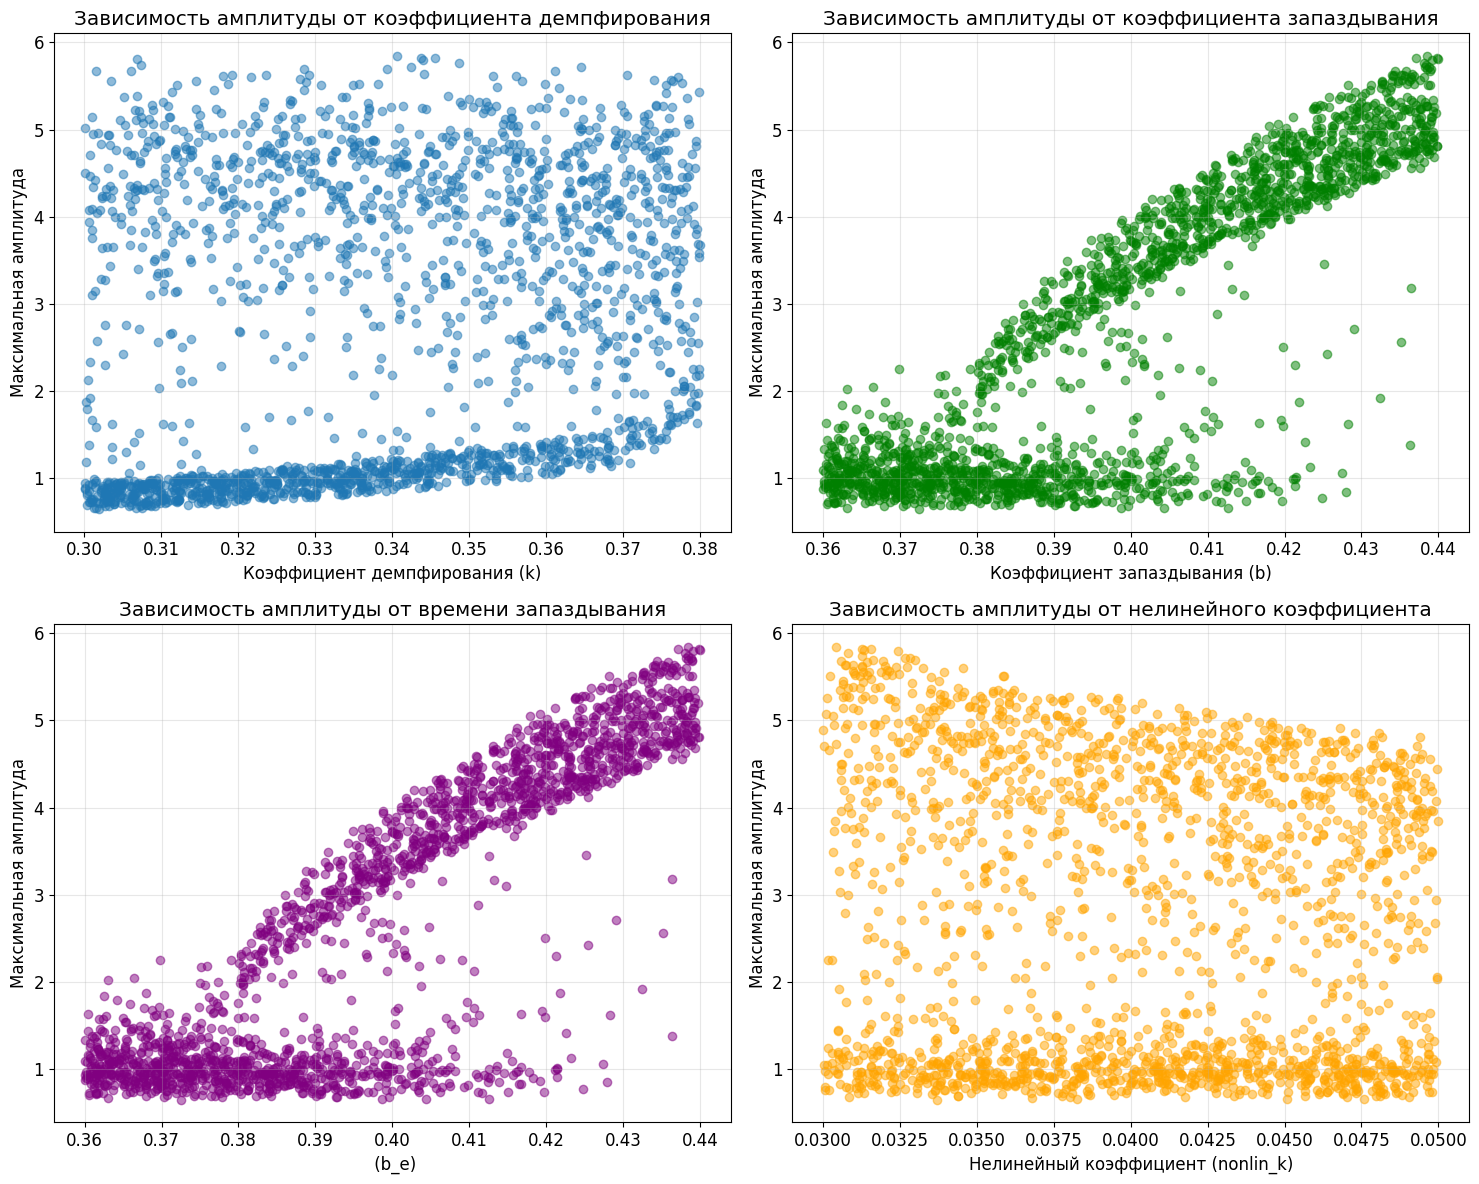

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Зависимость от коэффициента демпфирования (k)
axes[0, 0].scatter(df_traj['b'], df_traj['max_amplitude'], alpha=0.5)
axes[0, 0].set_xlabel('Коэффициент демпфирования (k)')
axes[0, 0].set_ylabel('Максимальная амплитуда')
axes[0, 0].set_title('Зависимость амплитуды от коэффициента демпфирования')
axes[0, 0].grid(True, alpha=0.3)

# Зависимость от коэффициента запаздывания (b)
axes[0, 1].scatter(df_traj['b_e'], df_traj['max_amplitude'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Коэффициент запаздывания (b)')
axes[0, 1].set_ylabel('Максимальная амплитуда')
axes[0, 1].set_title('Зависимость амплитуды от коэффициента запаздывания')
axes[0, 1].grid(True, alpha=0.3)

# Зависимость от времени запаздывания (tau)
axes[1, 0].scatter(df_traj['b_e'], df_traj['max_amplitude'], alpha=0.5, color='purple')
axes[1, 0].set_xlabel(' (b_e)')
axes[1, 0].set_ylabel('Максимальная амплитуда')
axes[1, 0].set_title('Зависимость амплитуды от времени запаздывания')
axes[1, 0].grid(True, alpha=0.3)

# Зависимость от нелинейного коэффициента (nonlin_k)
axes[1, 1].scatter(df_traj['nonlin_k'], df_traj['max_amplitude'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Нелинейный коэффициент (nonlin_k)')
axes[1, 1].set_ylabel('Максимальная амплитуда')
axes[1, 1].set_title('Зависимость амплитуды от нелинейного коэффициента')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Сохранение результатов анализа

In [ ]:
# Сохраняем сводную информацию о датасетах
df_info.to_csv('projects/create_datasets/dataset_summary.csv', index=False)

# Сохраняем данные о траекториях
df_traj.to_csv('projects/create_datasets/trajectory_data.csv', index=False)

print("Результаты анализа сохранены в CSV файлы:")
print("- projects/create_datasets/dataset_summary.csv")
print("- projects/create_datasets/trajectory_data.csv")